In [1]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import layers
import keras

In [8]:
num_tags = 12
num_words = 10000
num_departments = 4

title_input = layers.Input(shape=(None,),name="title")
body_input = layers.Input(shape=(None,),name="body")
tags_input = layers.Input(shape=(num_tags,),name="tags")

title_features = layers.Embedding(num_words,64)(title_input)
body_features = layers.Embedding(num_words,64)(body_input)

title_features = layers.LSTM(128)(title_features)
body_features = layers.LSTM(32)(body_features)

concatente = layers.concatenate(
    [title_features,body_features,tags_input],
)

priority_pred = layers.Dense(1,name="priority")(concatente)
department_pred = layers.Dense(4,name="department")(concatente)


multi_model = keras.Model(
    [title_input,body_input,tags_input],
    [priority_pred,department_pred]
    )

keras.utils.plot_model(multi_model,"./modelImage/multi_model.png",show_shapes=True)

multi_model.save_weights('multi_model.h5')

In [18]:
import tensorflow as tf

InputLayers = tf.keras.layers.Input(shape=[64,64,1])
ConvL1 = tf.keras.layers.Conv2D(3, kernel_size=5, activation='swish')(InputLayers)
ConvL2 = tf.keras.layers.Conv2D(6, kernel_size=5, activation='swish')(ConvL1)
FlattenL1 = tf.keras.layers.Flatten()(ConvL2)

# 19 21 27
# cho jung jong

DenseCho = tf.keras.layers.Dense(units=19, activation='softmax')(FlattenL1);
DenseJung = tf.keras.layers.Dense(units=21, activation='softmax')(FlattenL1);
DenseJong = tf.keras.layers.Dense(units=28, activation='softmax')(FlattenL1);

#DenseAvg = layers.average([DenseCho, DenseJung, DenseJong])

testModel = tf.keras.models.Model(InputLayers, FlattenL1)

keras.utils.plot_model(testModel,"./modelImage/testModel.png",show_shapes=True)
testModel.save_weights('testModel.h5')

In [ ]:
mergeModel = tf.keras.Sequential # 

In [16]:
def get_model():
    model = keras.models.Sequential()
    model.add(layers.Input(shape=(128,)))
    model.add(layers.Dense(1))
    return model

model1 = get_model()
model2 = get_model()
model3 = get_model()

input_layer = layers.Input(shape=(128,))
output_layer = layers.average([model1(input_layer),model2(input_layer),model3(input_layer)])

ensemble_model = keras.Model(input_layer,output_layer)


ensemble_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
ensemble_model.save_weights('ensemble_models.h5')

#keras.utils.plot_model(output_layer,"./modelImage/ensemble_model.png",show_shapes=True)
#keras.utils.plot_model(ensemble_model,"./modelImage/ensemble_model.png",show_shapes=True)
#ensemble_model.save_weights('my_model.h5')

AttributeError: 'KerasTensor' object has no attribute 'built'

In [1]:
keras.backend.clear_session()

# pytorch와 비슷한 방법
class MyModel(Model):
    def __init__(self):
        super(MyModel, self).__init__()
        self.dense1 = Dense(64, activation='relu')
        self.dense2 = Dense(10, activation='softmax')

    def call(self, x):
        x = self.dense1(x)
        x = self.dense2(x)
        return x
    
    def summary(self):
        inputs = Input((1, 10))
        Model(inputs, self.call(inputs)).summary()

# input입력으로 모델 생성(build를 해야하며, input_shape를 넣어줌)
model = MyModel()
model.build(input_shape=(1,10)) # (1, feature)

# 모델 요약
model.summary()

# 컴파일 및 학습
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.save_weights('my_model.h5')

#model.fit(x, y, epochs=20, verbose=1, validation_split=0.2, shuffle=True, batch_size=4)




Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1, 10)]           0         
                                                                 
 dense (Dense)               (None, 1, 64)             704       
                                                                 
 dense_1 (Dense)             (None, 1, 10)             650       
                                                                 
Total params: 1354 (5.29 KB)
Trainable params: 1354 (5.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________



In [21]:
model2 = keras.models.Sequential([
    keras.layers.Flatten(input_shape=(28, 28),name="layers1"),
    keras.layers.Dense(128, activation='relu',name="selected_layer"),
    keras.layers.Dropout(0.2,name="layers3"),
    keras.layers.Dense(10,name="layers4")
])

model2.summary()

# 컴파일 및 학습
model2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model2.save_weights('my_model2.h5')


keras.utils.plot_model(model2,"./modelImage/model.png",show_shapes=True)

keras.layers.Flatten(input_shape=(28, 28),name="layers1")
print(model2.layers)

model2.layers[0].dtype

model2.get_layer(name="selected_layer")

input = keras.layers.Input(shape=(28,28))

# 반환값은 출렉 레이어, 
# 입력 레이어도 있지만 현재 상태에서 참조 못함
x = keras.layers.Dense(64,activation="relu",name="layer")(input) 
print(x) 

model2.layers[0].input
model2.layers[0].output

model2.layers[1].input.shape

Model: "sequential_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 layers1 (Flatten)           (None, 784)               0         
                                                                 
 selected_layer (Dense)      (None, 128)               100480    
                                                                 
 layers3 (Dropout)           (None, 128)               0         
                                                                 
 layers4 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
[<keras.src.layers.reshaping.flatten.Flatten object at 0x000001E7D7447BB0>, <keras.src.layers.core.dense.Dense object at 0x000001E7D6FCD060>, <ke

TensorShape([None, 784])

In [30]:
model = keras.Sequential([
    keras.Input(shape=(784)),
    layers.Dense(32, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10),
])

# Presumably you would want to first load pre-trained weights.
model.load_weights(...)

# Freeze all layers except the last one.
for layer in model.layers[:-1]:
    layer.trainable = False

# Recompile and train (this will only update the weights of the last layer).
model.compile(...)
model.fit(...)


AttributeError: 'ellipsis' object has no attribute 'endswith'

In [22]:
model3 = keras.models.Sequential()
model3.add(keras.layers.Flatten(input_shape=(28, 28),name="layers1"))
model3.add(keras.layers.Dense(128, activation='relu',name="selected_layer"))
model3.add(keras.layers.Dropout(0.2))
model3.add(keras.layers.Dense(10))

model3.summary()

# 컴파일 및 학습
model3.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model3.save_weights('my_model3.h5')

Model: "sequential_17"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 layers1 (Flatten)           (None, 784)               0         
                                                                 
 selected_layer (Dense)      (None, 128)               100480    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Model: "encoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 original_img (InputLayer)   [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_8 (Conv2D)           (None, 26, 26, 16)        160       
                                                                 
 conv2d_9 (Conv2D)           (None, 24, 24, 32)        4640      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 8, 8, 32)          0         
 g2D)                                                            
                                                                 
 conv2d_10 (Conv2D)          (None, 6, 6, 32)          9248      
                                                                 
 conv2d_11 (Conv2D)          (None, 4, 4, 16)          4624      
                                                           

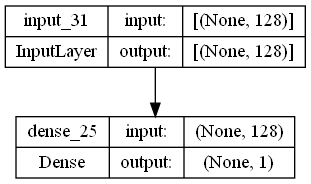

In [37]:
def get_model():
    model = keras.models.Sequential()
    model.add(layers.Input(shape=(128,)))
    model.add(layers.Dense(1))
    return model


encoder_input = keras.Input(shape=(28, 28, 1), name="original_img")
x = layers.Conv2D(16, 3, activation="relu")(encoder_input)
x = layers.Conv2D(32, 3, activation="relu")(x)
x = layers.MaxPooling2D(3)(x)
x = layers.Conv2D(32, 3, activation="relu")(x)
x = layers.Conv2D(16, 3, activation="relu")(x)
encoder_output = layers.GlobalMaxPooling2D(name="encorder_output")(x)

encoder = keras.Model(encoder_input, encoder_output, name="encoder")
encoder.summary()

decoder_input = keras.Input(shape=(16,), name="encoded_img")
x = layers.Reshape((4, 4, 1))(decoder_input)
x = layers.Conv2DTranspose(16, 3, activation="relu")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu")(x)
x = layers.UpSampling2D(3)(x)
x = layers.Conv2DTranspose(16, 3, activation="relu")(x)
decoder_output = layers.Conv2DTranspose(1, 3, activation="relu",name="decorder_output")(x)

decoder = keras.Model(decoder_input, decoder_output, name="decoder")
decoder.summary()

autoencoder_input = keras.Input(shape=(28, 28, 1), name="img")
encoded_img = encoder(autoencoder_input)
decoded_img = decoder(encoded_img)
autoencoder = keras.Model(autoencoder_input, decoded_img, name="autoencoder")

model1 = get_model()
model2 = get_model()
model3 = get_model()

input_layer = layers.Input(shape=(128,))
output_layer = layers.average([model1(input_layer),model2(input_layer),model3(input_layer)])

ensemble_model = keras.Model(input_layer,output_layer)


# 모델 요약
ensemble_model.summary()

# 컴파일 및 학습
ensemble_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
ensemble_model.save_weights('ensemble_models.h5')

keras.utils.plot_model(model2,"./modelImage/ensemble_model.png",show_shapes=True)
